# Resultados del árbol de decisión

Este notebook concentra las métricas, gráficos y resultados del modelo de árbol de decisión.

In [33]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl


def encontrar_base_dir():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "evaluacion" / "ev_arbol_decision.py").exists():
            return candidate
    raise FileNotFoundError("No se encontró el archivo ev_arbol_decision.py")


base_dir = encontrar_base_dir()
module_path = base_dir / "src" / "evaluacion" / "ev_arbol_decision.py"
spec = spec_from_file_location("ev_arbol_decision", module_path)
evaluacion = module_from_spec(spec)
spec.loader.exec_module(evaluacion)

accuracy = evaluacion.metrics["accuracy"]
cm = evaluacion.metrics["confusion_matrix"]
df_report = evaluacion.df_report
labels = list(evaluacion.modelo.classes_)

print(f"Precición del modelo de árbol de decisión: {accuracy*100:.2f}%")

Precición del modelo de árbol de decisión: 36.67%


### Conclusión de la métrica

La exactitud observada es baja para un problema de tres clases, porque el árbol solo acierta una parte limitada de los casos. En AgroIntelligence esto sugiere que las variables IoT y de cultivo sí aportan señal, pero todavía no separan con claridad la calidad del fruto en todas las categorías.

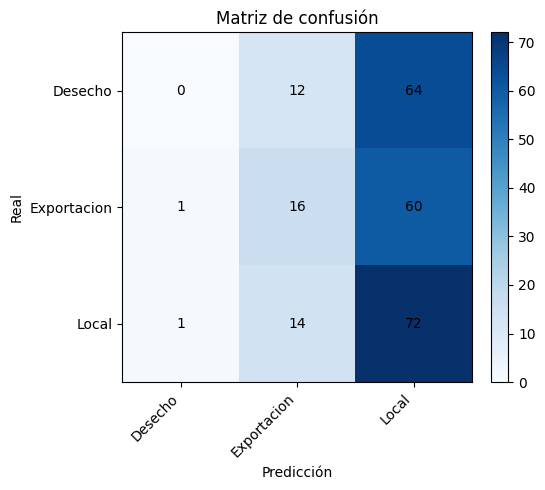

,precision,recall,f1-score,support
Desecho,0.000000,0.000000,0.000000,76.000000
Exportacion,0.380952,0.207792,0.268908,77.000000
Local,0.367347,0.827586,0.508834,87.000000
accuracy,0.366667,0.366667,0.366667,0.366667
macro avg,0.249433,0.345126,0.259247,240.000000
weighted avg,0.255385,0.366667,0.270727,240.000000


In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, cm[row, col], ha="center", va="center", color="black")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

df_report

### Conclusión del gráfico y del resultado

La matriz de confusión muestra que la clase `Local` es la mejor reconocida, mientras que `Desecho` y `Exportación` se confunden con mayor frecuencia. Esto indica que el modelo aún mezcla estados de calidad cercanos, aunque al limitar la profundidad se vuelve más simple y menos propenso a memorizar los datos.

## Optimización de hiperparámetros

En este caso se comparan dos estrategias de búsqueda para el árbol de decisión:

- GridSearchCV: prueba todas las combinaciones definidas en una grilla.
- RandomizedSearchCV: prueba una muestra aleatoria de combinaciones, útil cuando el espacio de búsqueda es grande.

Para AgroIntelligence, estas técnicas ayudan a encontrar una configuración que aproveche mejor las variables IoT del cultivo y mejore la clasificación de la calidad del fruto.

In [35]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path


def encontrar_base_dir():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "optimizacion" / "op_arbol_decision.py").exists():
            return candidate
    raise FileNotFoundError("No se encontró el archivo op_arbol_decision.py")


base_dir = encontrar_base_dir()
module_path_opt = base_dir / "src" / "optimizacion" / "op_arbol_decision.py"
spec_opt = spec_from_file_location("op_arbol_decision", module_path_opt)
optimizacion = module_from_spec(spec_opt)
spec_opt.loader.exec_module(optimizacion)

resumen_busquedas = optimizacion.resumen_busquedas
mejor_metodo = optimizacion.metrics["best_method"]
mejor_score_cv = optimizacion.metrics["best_cv_score"]
mejores_parametros = optimizacion.metrics["best_params"]
accuracy_optimizada = optimizacion.metrics["accuracy"]

resumen_busquedas

,metodo,mejor_score_cv,accuracy_test,mejores_parametros
0,GridSearchCV,0.35000,0.379167,"{'clasificador__criterion': 'gini', 'clasifica..."
1,RandomizedSearchCV,0.35625,0.370833,"{'clasificador__criterion': 'log_loss', 'clasi..."


### Conclusión de la optimización

La comparación entre GridSearchCV y RandomizedSearchCV permite medir si conviene explorar la grilla completa o buscar combinaciones al azar. En AgroIntelligence, el criterio final debe ser el score de validación cruzada junto con el desempeño en prueba, porque eso indica qué configuración generaliza mejor dentro de un árbol controlado en profundidad.

### Gráfico del árbol de decisión

El gráfico muestra solo los primeros niveles del árbol base no optimizado para que la estructura sea legible. Se limita la profundidad a 3 para mantener el modelo simple, interpretable y con menos riesgo de sobreajuste.

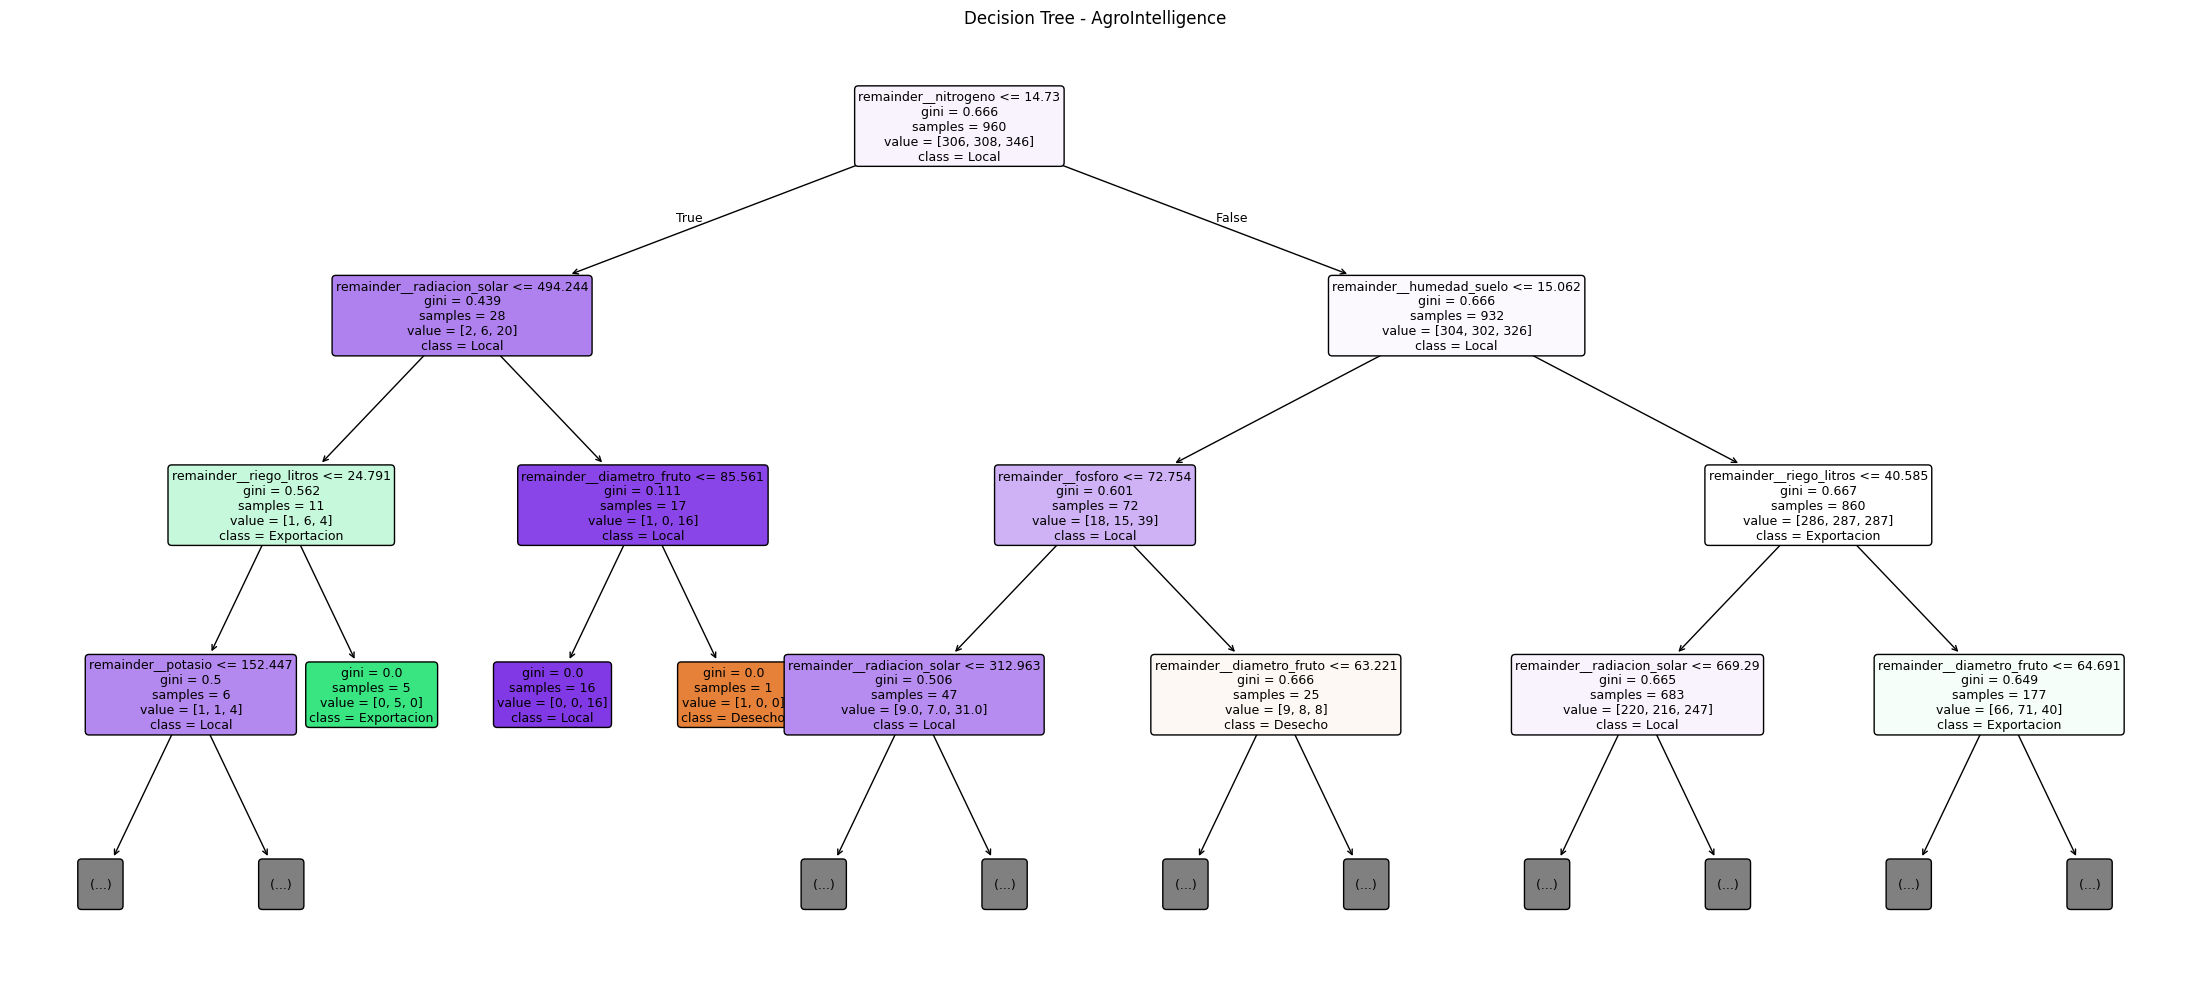

In [36]:
from sklearn.tree import plot_tree

clasificador = modelo.named_steps["clasificador"]
preprocesador = modelo.named_steps["preprocesamiento"]
feature_names = preprocesador.get_feature_names_out()
class_names = modelo.classes_

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    clasificador,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
plt.title("Decision Tree - AgroIntelligence")
plt.tight_layout()
plt.show()

### Conclusión del árbol

El árbol permite ver qué variables toman primero el control de la predicción. En AgroIntelligence, eso nos dice cuáles señales de los sensores y del cultivo están siendo más útiles para separar la calidad del fruto, aunque al limitar la profundidad a 3 también se nota que la frontera entre clases sigue siendo compleja. En otras palabras, el modelo capta patrones importantes, pero prioriza simplicidad e interpretabilidad antes que memorizar los datos.